# Regulatory Network Analysis of Stem Cells using scPRINT

* **Author**: Anna Maguza 
* **Location**: CellZome, GSK company
* **Creation date**: 20.08.2025
* **Last modified date**: 29.08.2025

In [1]:
from huggingface_hub import hf_hub_download

from scprint import scPrint
from scdataloader import Preprocessor, utils
from scdataloader.preprocess import additional_preprocess
from scdataloader.utils import load_genes
from scprint.tasks import GNInfer
from grnndata import utils as grnutils
from grnndata import read_h5ad

import lamindb as ln
import scanpy as sc
import numpy as np
from pybiomart import Dataset
from matplotlib import pyplot as plt
import pandas as pd
import json
from anndata.utils import make_index_unique

import gseapy as gp
from gseapy import dotplot
from pyvis import network as pnx
import networkx as nx
import scipy.sparse

%load_ext autoreload
%autoreload 2 

import torch
torch.set_float32_matmul_precision('medium')

import os
import ssl
import urllib3

No module named 'triton'
FlashAttention is not installed, not using it..


/Users/am336941/uv_envs/scprint_env230/scprint_env230/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


→ connected lamindb: anonymous/test


## Preprocessing

In [ ]:
adata = sc.read_h5ad("data/gut_data/gut_hs_full_annotated_AM_06032025_140458_raw.h5ad")
adata

AnnData object with n_obs × n_vars = 365542 × 43704
    obs: 'cell_index', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_pro

In [3]:
adata.var

""
WASH7P
ENSG00000238009
CICP27
ENSG00000268903
ENSG00000269981
...
ENSG00000277836
ENSG00000278633
ENSG00000276017
ENSG00000278817


### Load ontology mapping file

In [4]:
with open('ontology_terms.json', 'r') as f:
    ontology_data = json.load(f)

cell_type_mapping = {item['cell_annotation']: item['ontology_term'] 
                     for item in ontology_data['ontology_terms']}
tissue_mapping = {item['tissue']: item['ontology_term'] 
                  for item in ontology_data['tissue_mapping']}
sex_mapping = ontology_data['sex_mapping']
age_group_mapping = ontology_data['age_group_mapping']
assay_mapping = ontology_data['assay_mapping']

In [5]:
adata.obs['organism'] = 'Homo sapiens'
adata.obs['organism_ontology_term_id'] = 'NCBITaxon:9606'

In [6]:
# Map cell_states to cell_type_ontology_term_id
adata.obs['cell_type_ontology_term_id'] = 'unknown'
for cell_type in adata.obs['cell_states'].unique():
    if cell_type in cell_type_mapping:
        ontology_id = cell_type_mapping[cell_type]
        mask = adata.obs['cell_states'] == cell_type
        adata.obs.loc[mask, 'cell_type_ontology_term_id'] = ontology_id
    else:
        print(f"No mapping found for '{cell_type}', keeping as 'unknown'")

In [7]:
# Map age_group to development_stage_ontology_term_id
adata.obs['development_stage_ontology_term_id'] = adata.obs['age_group'].map(age_group_mapping)

In [8]:
# Map gut_region to tissue_ontology_term_id 
if 'gut_region' in adata.obs.columns:
    adata.obs['tissue_ontology_term_id'] = adata.obs['gut_region'].map(tissue_mapping)
else:
    adata.obs['tissue_ontology_term_id'] = 'unknown'


In [9]:
# Map sex to sex_ontology_term_id 
if 'sex' in adata.obs.columns:
    # Convert to string to handle categorical issues
    adata.obs['sex_normalized'] = adata.obs['sex'].astype(str).str.lower()
    adata.obs['sex_ontology_term_id'] = adata.obs['sex_normalized'].map(sex_mapping).fillna('unknown')
    adata.obs.drop('sex_normalized', axis=1, inplace=True)
else:
    adata.obs['sex_ontology_term_id'] = 'unknown'

In [10]:
# Map library_preparation_protocol to assay_ontology_term_id
protocol_str = adata.obs['library_preparation_protocol'].astype(str)
adata.obs['assay_ontology_term_id'] = protocol_str.map(assay_mapping).fillna('EFO:0008913')

In [11]:
adata.obs['self_reported_ethnicity_ontology_term_id'] = 'unknown'
adata.obs['disease_ontology_term_id'] = 'PATO:0000461'  # normal

In [12]:
required_cols = ['organism_ontology_term_id', 'cell_type_ontology_term_id', 'tissue_ontology_term_id', 
                'assay_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id',
                'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id']
missing_cols = [col for col in required_cols if col not in adata.obs.columns]
print(f"WARNING: Missing required columns: {missing_cols}")


In [13]:
adata.var["gene_symbol"] = adata.var.index.copy()

In [14]:
adata.var

,gene_symbol
WASH7P,WASH7P
ENSG00000238009,ENSG00000238009
CICP27,CICP27
ENSG00000268903,ENSG00000268903
ENSG00000269981,ENSG00000269981
...,...
ENSG00000277836,ENSG00000277836
ENSG00000278633,ENSG00000278633
ENSG00000276017,ENSG00000276017
ENSG00000278817,ENSG00000278817


In [15]:
dataset = Dataset(name='hsapiens_gene_ensembl', host='http://www.ensembl.org')

In [16]:
biomart_results = dataset.query(attributes=['ensembl_gene_id', 'external_gene_name'])

In [17]:
biomart_results

,Gene stable ID,Gene name
0,ENSG00000210049,MT-TF
1,ENSG00000211459,MT-RNR1
2,ENSG00000210077,MT-TV
3,ENSG00000210082,MT-RNR2
4,ENSG00000209082,MT-TL1
...,...,...
86359,ENSG00000197989,SNHG12
86360,ENSG00000229388,TAF12-DT
86361,ENSG00000289291,NaN
86362,ENSG00000274978,RNU11


In [18]:
adata.var

,gene_symbol
WASH7P,WASH7P
ENSG00000238009,ENSG00000238009
CICP27,CICP27
ENSG00000268903,ENSG00000268903
ENSG00000269981,ENSG00000269981
...,...
ENSG00000277836,ENSG00000277836
ENSG00000278633,ENSG00000278633
ENSG00000276017,ENSG00000276017
ENSG00000278817,ENSG00000278817


In [19]:
# Create a mapping dictionary from biomart_results
gene_id_map = biomart_results.set_index('Gene name')['Gene stable ID'].to_dict()

# Add ensembl gene IDs to adata.var
adata.var['gene_id-query'] = adata.var['gene_symbol'].map(gene_id_map)

# Fill missing values with the corresponding index values
adata.var['gene_id-query'] = adata.var['gene_id-query'].fillna(adata.var.index.to_series())

In [20]:
adata.var.index = adata.var['gene_id-query'].copy()

In [21]:
# Check for duplicates in var index
duplicates = adata.var.index.duplicated()
duplicates

array([False, False, False, ..., False, False, False])

In [22]:
if adata.var.index.duplicated().any():
    adata = adata[:, ~adata.var.index.duplicated(keep='first')]

### Preprocessor module
scPRINT converts the gene expression of a cell to an embedding by summing three representations or tokens: its id, expression, and genomic location scdataloader. The Preprocessor module specifically handles:

Gene ID Encoding: scPRINT encodes the gene IDs using protein embeddings. This gene representation is made using the ESM2 amino-acid embedding of its most common protein product.   
Expression Embedding: The gene's expression is tokenized via a multi-layer perceptron (MLP) using log-normalized counts. This MLP lets the model learn a metric behind gene expression.   
Positional Encoding: We help the model know that genes with similar locations tend to be regulated by identical DNA regions, using the positional encoding of their location in the genome.   

The preprocessor makes sure that the fields are all here, the genes are in the right format, the raw counts are used.

In [23]:
preprocessor = Preprocessor(
    do_postp=True, # takes too much RAM in collab to do PCA
    # additional_postprocess=additional_postprocess,
    additional_preprocess=additional_preprocess,
    force_preprocess=True,
)

In [24]:
adata.var.index = adata.var["gene_id-query"].astype(str).copy()

In [25]:
adata = preprocessor(adata)

Dropping layers:  KeysView(Layers with keys: )
checking raw counts
removed 0 non primary cells, 365542 renamining
filtered out 1515 cells, 364027 renamining
Removed 1376 genes not known to the ontology
Removed 0 duplicate genes
Added 28299 genes in the ontology but not present in the dataset
validating


/Users/am336941/uv_envs/scprint_env230/scprint_env230/lib/python3.10/site-packages/scdataloader/preprocess.py:287: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  adata, organism=adata.obs.organism_ontology_term_id[0], need_all=False


! received 5 unique terms, 364022 empty/duplicated terms are ignored
! 1 unique term (20.00%) is not validated for ontology_id: 'unknown'
starting QC
Seeing 123567 outliers (33.94% of total dataset):
normalize
starting PCA
done
AnnData object with n_obs × n_vars = 364027 × 70611
    obs: 'cell_index', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_f

In [26]:
file = ln.Artifact.from_anndata(adata, description="test anndata")
file.save()
col = ln.Collection(file, name="test")
col.save()

! no run & transform got linked, call `ln.track()` & re-run


... storing 'organism' as categorical
... storing 'organism_ontology_term_id' as categorical
... storing 'cell_type_ontology_term_id' as categorical
... storing 'sex_ontology_term_id' as categorical
... storing 'assay_ontology_term_id' as categorical
... storing 'self_reported_ethnicity_ontology_term_id' as categorical
... storing 'disease_ontology_term_id' as categorical
... storing 'cell_culture' as categorical
... storing 'batches' as categorical
... storing 'gene_symbol' as categorical
... storing 'gene_id-query' as categorical
... storing 'symbol' as categorical
... storing 'biotype' as categorical
... storing 'organism' as categorical


! no run & transform got linked, call `ln.track()` & re-run
! run input wasn't tracked, call `ln.track()` and re-run


/var/folders/8j/syfvxwvd4lggpmnnpd_r8jkr0000gp/T/ipykernel_59271/1650442001.py:3: FutureWarning: argument `name` will be removed, please pass test to `key` instead
  col = ln.Collection(file, name="test")


Collection(uid='r9Oyq1vGYF8Azz8m0000', is_latest=True, key='test', hash='9QQR0RcQ40VpUezijaTteA', created_by_id=1, space_id=1, created_at=2025-08-29 07:12:02 UTC)

### Loading the model

In [27]:
# Disable SSL warnings
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# Set environment variables to disable SSL verification
os.environ['PYTHONHTTPSVERIFY'] = '0'
os.environ['CURL_CA_BUNDLE'] = ''
os.environ['REQUESTS_CA_BUNDLE'] = ''
os.environ['SSL_VERIFY'] = 'false'

# Configure SSL context
ssl._create_default_https_context = ssl._create_unverified_context

# Configure requests to not verify SSL
import requests.packages.urllib3.util.ssl_
requests.packages.urllib3.util.ssl_.DEFAULT_CIPHERS = 'ALL'

# Monkey patch requests to disable SSL verification
original_request = requests.Session.request
def patched_request(self, method, url, **kwargs):
    kwargs['verify'] = False
    return original_request(self, method, url, **kwargs)
requests.Session.request = patched_request

# Now download the model
model_checkpoint_file = hf_hub_download(
    repo_id="jkobject/scPRINT", 
    filename="v2-medium.ckpt"
)

In [28]:
model_checkpoint_file 

'/Users/am336941/.cache/huggingface/hub/models--jkobject--scPRINT/snapshots/d79fad0ff77e19d9ba0c2fad9dfc993b37e92d6d/v2-medium.ckpt'

In [29]:
# make sure that you check if you have a GPU with flashattention or not (see README)
try:
    m = torch.load(model_checkpoint_file)
# if not use this instead since the model weights are by default mapped to GPU types
except RuntimeError: 
    m = torch.load(model_checkpoint_file, map_location=torch.device('cpu'))

In [30]:
# again here by default the model was trained with flash attention, so if you do not have a GPU you will need to replace the attention mechanism with regular attention 
transformer = "flash" if torch.cuda.is_available() else "normal"

In [31]:
# both are for compatibility issues with different versions of the pretrained model, so we need to load it with the correct transformer
if "prenorm" in m['hyper_parameters']:
    m['hyper_parameters'].pop("prenorm")
    torch.save(m, model_checkpoint_file)
if "label_counts" in m['hyper_parameters']:
    # you need to set precpt_gene_emb=None otherwise the model will look for its precomputed gene embeddings files although they were already converted into model weights, so you don't need this file for a pretrained model
    model = scPrint.load_from_checkpoint(model_checkpoint_file, precpt_gene_emb=None, classes=m['hyper_parameters']['label_counts'], transformer=transformer)
else:
    model = scPrint.load_from_checkpoint(model_checkpoint_file, precpt_gene_emb=None, transformer=transformer)

RuntimeError caught: scPrint is not attached to a `Trainer`.


In [32]:
# this might happen if you have a model that was trained with a different set of genes than the one you are using in the ontology (e.g. newer ontologies), While having genes in the onlogy not in the model is fine. the opposite is not, so we need to remove the genes that are in the model but not in the ontology
missing = set(model.genes) - set(load_genes(model.organisms).index)
if len(missing) > 0:
    print(
        "Warning: some genes missmatch exist between model and ontology: solving...",
    )

In [33]:
# again if not on GPU you need to convert the model to float64
if not torch.cuda.is_available():
    model = model.to(torch.float32)
    
# you can perform your inference on float16 if you have a GPU, otherwise use float64
dtype = torch.float16 if torch.cuda.is_available() else torch.float32

# the models are often loaded with some parts still displayed as "cuda" and some as "cpu", so we need to make sure that the model is fully on the right device 
model = model.to("cuda" if torch.cuda.is_available() else "cpu")

## Download data and filter

In [34]:
#sc.pp.filter_genes(adata, min_cells=1)

In [35]:
adata.layers["counts"] = adata.X.copy()

In [36]:
sc.pp.highly_variable_genes(adata, 
                            n_top_genes=3000, 
                            batch_key="sample_id",
                            layer="counts",
                            flavor="seurat_v3",
                            subset=False,  # Don't subset - just mark highly variable genes
                            span=1)

# Let's see how many highly variable genes we have
print(f"Number of highly variable genes: {adata.var['highly_variable'].sum()}")
print(f"Total genes: {adata.n_vars}")

Number of highly variable genes: 3000
Total genes: 70611


In [37]:
# Keep the filtered dataset for GRN inference
print(f"Filtered dataset shape: {adata.shape}")
print(f"Number of highly variable genes: {adata.n_vars}")

Filtered dataset shape: (364027, 70611)
Number of highly variable genes: 70611


### Gene network inference

Finally we will use scPRINT to infer gene networks on another cell of interest, the fibroblasts, in both normal and BPH conditions.

In [38]:
grn_inferer = GNInfer(
                    # here we use the most variable genes - this will automatically select from highly variable genes
                    how="most expr",  # corrected to "most var" based on the actual error message
                    # we will preprocess the attention matrix with softmax
                    preprocess="softmax",
                    # we don't aggregate the heads here, we will do it manually
                    head_agg='mean',
                    # we will not use any filtration here, but you can use "none" or "topk" for top k connections per genes or "thresh" for a defined threshold, and more
                    filtration="none",
                    # here if we generate the attention matrices by performing a task, like denoising or by just passing the expression profile through the model
                    forward_mode="none",
                    # use the 3000 highly variable genes
                    num_genes=3000,  # this will select from the marked highly variable genes
                    doplot=True,
                    batch_size=8,
                    cell_type_col = "cell_states",
                    # disable multiprocessing to avoid collator issues
                    num_workers=0,  # set to 0 to avoid multiprocessing errors,
                    dtype=dtype,
                    # list of layers to use
                    layer=list(range(model.nlayers))[:]
                    )

Some valid genes are not in the genedf!!!


100%|██████████| 1472/1472 [58:49<00:00,  2.40s/it] 
/Users/am336941/uv_envs/scprint_env230/scprint_env230/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/am336941/uv_envs/scprint_env230/scprint_env230/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


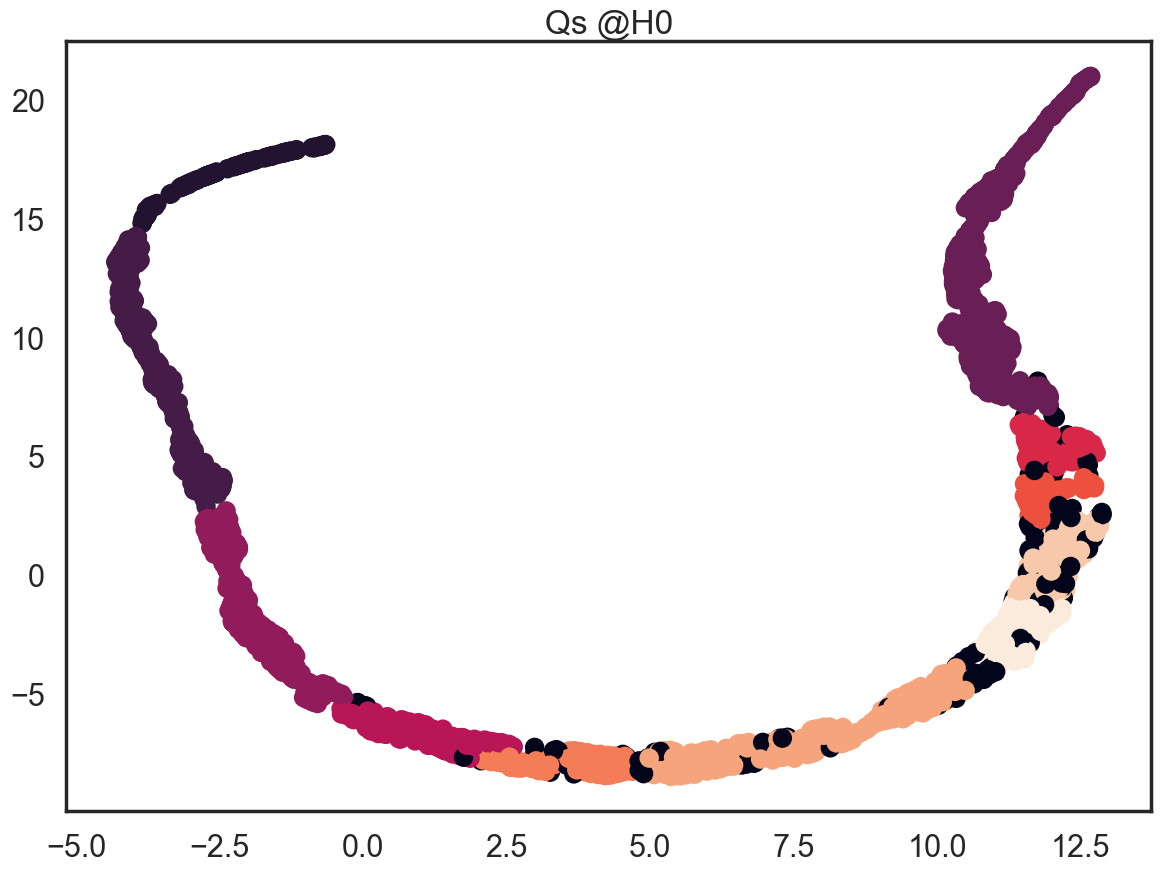

/Users/am336941/uv_envs/scprint_env230/scprint_env230/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/am336941/uv_envs/scprint_env230/scprint_env230/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


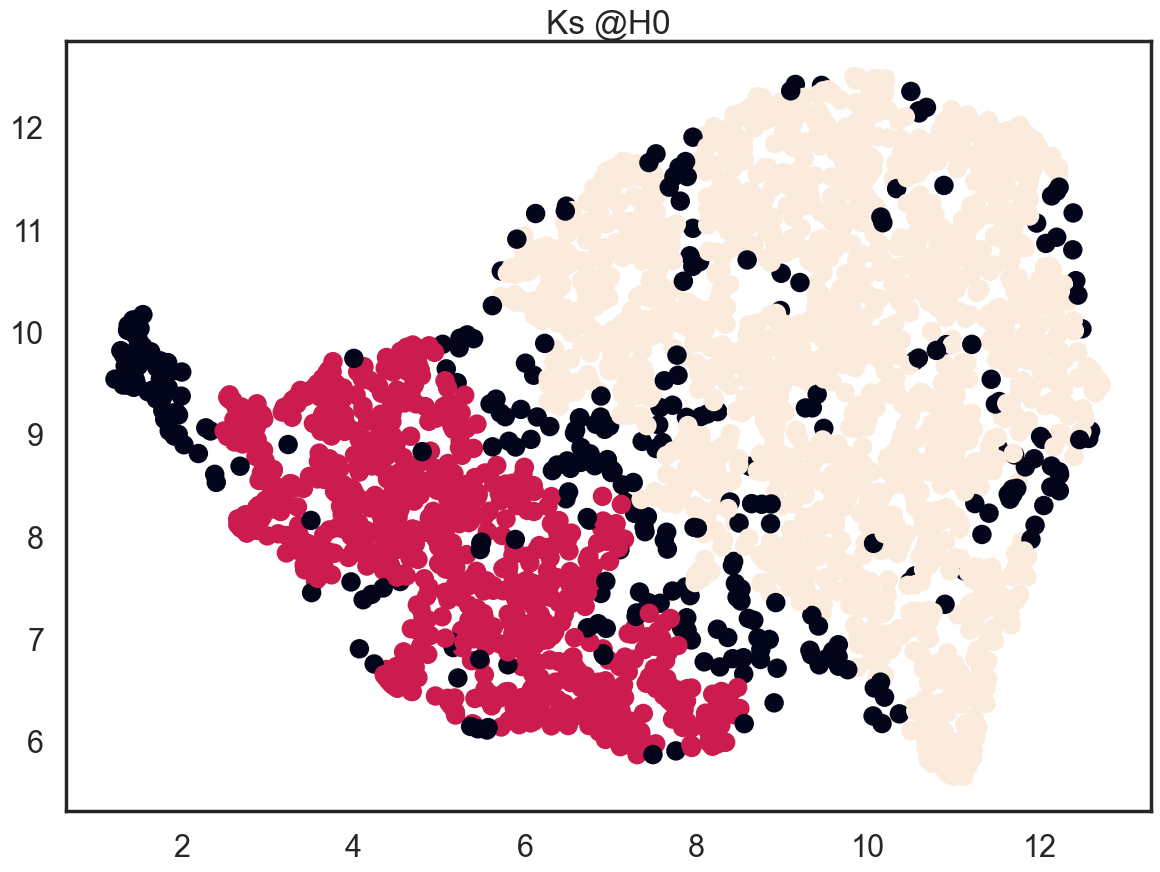

avg link count: 8785296, sparsity: 1.0


In [39]:
# Use this dataset for GRN inference
grn_full = grn_inferer(model, adata, cell_type="Stem cells")

In [40]:
grn_full.var

,gene_symbol,gene_id-query,uid,symbol,biotype,organism_id,mt,ribo,hb,organism,ensembl_gene_id,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,highly_variable,highly_variable_rank,means,variances,variances_norm,highly_variable_nbatches,TFs
ENSG00000000003,TSPAN6,ENSG00000000003,1uTi9dROoaN5,TSPAN6,protein_coding,105,False,False,False,NCBITaxon:9606,ENSG00000000003,95724,0.678158,0.517697,73.704148,246868.0,12.416613,False,1429.5,0.678158,5.890866,0.883172,46,False
ENSG00000000419,DPM1,ENSG00000000419,4eC1wUNJAO2s,DPM1,protein_coding,105,False,False,False,NCBITaxon:9606,ENSG00000000419,89280,0.414747,0.346951,75.474347,150979.0,11.924903,False,1365.5,0.414747,1.192742,0.769838,20,False
ENSG00000001036,FUCA2,ENSG00000001036,5kgAeF5qhzAi,FUCA2,protein_coding,105,False,False,False,NCBITaxon:9606,ENSG00000001036,79242,0.493647,0.401221,78.231834,179701.0,12.099055,False,1586.0,0.493647,2.935565,0.868548,25,False
ENSG00000002330,BAD,ENSG00000002330,gMmTt1HAI7W6,BAD,protein_coding,105,False,False,False,NCBITaxon:9606,ENSG00000002330,106650,0.510086,0.412166,70.702723,185685.0,12.131812,False,1198.0,0.510086,1.495184,0.534847,3,False
ENSG00000002549,LAP3,ENSG00000002549,6fLdzqknq0uS,LAP3,protein_coding,105,False,False,False,NCBITaxon:9606,ENSG00000002549,64433,0.292176,0.256328,82.299939,106360.0,11.574594,False,1979.0,0.292176,0.832265,0.733271,12,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000277656,GSTT1,ENSG00000277656,53BNnegO8WAF,GSTT1,protein_coding,105,False,False,False,NCBITaxon:9606,ENSG00000277656,67176,0.385021,0.325715,81.546424,140158.0,11.850533,False,2345.5,0.385021,1.858236,0.492508,8,False
ENSG00000281484,BTG3,ENSG00000281484,2H0Pq8gQAzB3,BTG3,protein_coding,105,False,False,False,NCBITaxon:9606,ENSG00000281484,65697,0.317529,0.275758,81.952712,115589.0,11.657805,False,1593.0,0.317529,1.104839,0.765588,19,False
ENSG00000281763,DHX36,ENSG00000281763,lvqHrimctZn9,DHX36,protein_coding,105,False,False,False,NCBITaxon:9606,ENSG00000281763,95863,0.463551,0.380866,73.665964,168745.0,12.036150,False,1318.5,0.463551,1.397321,0.627693,14,False
ENSG00000282307,SERPINF1,ENSG00000282307,4JwrQDnTaggf,SERPINF1,protein_coding,105,False,False,False,NCBITaxon:9606,ENSG00000282307,36015,0.273095,0.241451,90.106503,99414.0,11.507058,True,826.0,0.273095,3.447678,1.211602,77,False


In [ ]:
grn_full.write_h5ad("/Fetal_stem_cells_analysis/1_scPRINT/data/grn_all.h5ad")

## Processing GRN Object for Analysis

Let's process the grn_full object similar to the cancer tutorial to enable detailed network analysis.

In [42]:
# Remove duplicates and process gene symbols
grn_full.var.symbol = make_index_unique(grn_full.var.symbol.astype(str))

# Convert gene ids to symbols for better readability
grn_full.var['ensembl_id'] = grn_full.var.index
grn_full.var.index = grn_full.var.symbol

print(f"GRN shape: {grn_full.shape}")
print(f"Number of genes: {grn_full.n_vars}")
print(f"Number of cells/observations: {grn_full.n_obs}")

GRN shape: (11774, 2955)
Number of genes: 2955
Number of cells/observations: 11774


## Hub Genes Analysis

We'll analyze hub genes using degree centrality (number of connections) and eigenvector centrality.

In [43]:
# Hub genes based on edge centrality (number of connections / strength of connections)
print("Top 20 hub genes by connection strength:")
top_hubs = grn_full.grn.sum(0).sort_values(ascending=False).head(20)
print(top_hubs)

Top 20 hub genes by connection strength:
symbol
PRRC2B      106.764130
RPL26L1      99.826996
GYPC         65.443184
TMEM126A     61.628494
HES4         57.852936
KRT18        35.098747
BCLAF1       34.888306
KRT8         24.062721
LAGE3        23.772720
ASH1L        23.490873
NIPBL        21.972727
MRPS11       20.755060
EIF2B1       18.396917
MRPL36       16.741909
POP7         15.693915
PJA1         14.748929
ARMC1        14.717377
FKBP7        12.658651
CRIP2        12.223820
LPP          10.816943
dtype: float32


In [44]:
# Compute eigenvector centrality by creating a sparse network with top 20 neighbors per gene
TOP = 20

print("Computing centrality measures...")
grnutils.get_centrality(grn_full, TOP, top_k_to_disp=0)

print("Top 20 genes by eigenvector centrality:")
top_centrality = grn_full.var.centrality.sort_values(ascending=False).head(20)
print(top_centrality)

Computing centrality measures...
Top central genes: []
Top 20 genes by eigenvector centrality:
symbol
GYPC        0.260853
RPL26L1     0.260758
BCLAF1      0.260272
KRT18       0.250825
NIPBL       0.248657
HES4        0.248620
TMEM126A    0.247421
MRPS11      0.243668
LAGE3       0.238441
PRRC2B      0.229885
KRT8        0.229708
ASH1L       0.220235
MRPL36      0.217631
CRIP2       0.193334
EIF2B1      0.189700
PJA1        0.176578
FKBP7       0.170107
ARMC1       0.144427
POP7        0.139205
RPSA        0.128997
Name: centrality, dtype: float64


## Network Communities Detection

Using Leiden algorithm to find communities in the network, focusing on communities between 20-200 genes.

In [45]:
# Compute clusters using Leiden algorithm
print("Computing network communities...")
grn_full = grnutils.compute_cluster(grn_full, resolution=1.5, use="leiden", n_iterations=10, max_comm_size=200)

# Show community sizes
community_counts = grn_full.var['cluster_1.5'].value_counts()
print("Community sizes:")
print(community_counts.head(10))

Computing network communities...
Community sizes:
cluster_1.5
0     200
7     200
11    200
1     200
9     200
8     200
10    200
6     200
5     200
4     200
Name: count, dtype: int64


In [46]:
# Visualize a specific community (e.g., largest community)
largest_community = community_counts.index[0]
print(f"Analyzing community {largest_community} with {community_counts.iloc[0]} genes")

# Get genes in the largest community
community_genes = grn_full.var[grn_full.var['cluster_1.5'] == largest_community].index.tolist()
print(f"Genes in community {largest_community}:")
print(community_genes[:10])  # Show first 10 genes

Analyzing community 0 with 200 genes
Genes in community 0:
['TFPI', 'TSR3', 'CD74', 'SERPINB1', 'BCLAF1', 'GPBP1', 'EIF4B', 'ZC3H15', 'KLF6', 'ACTB']


['#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4'

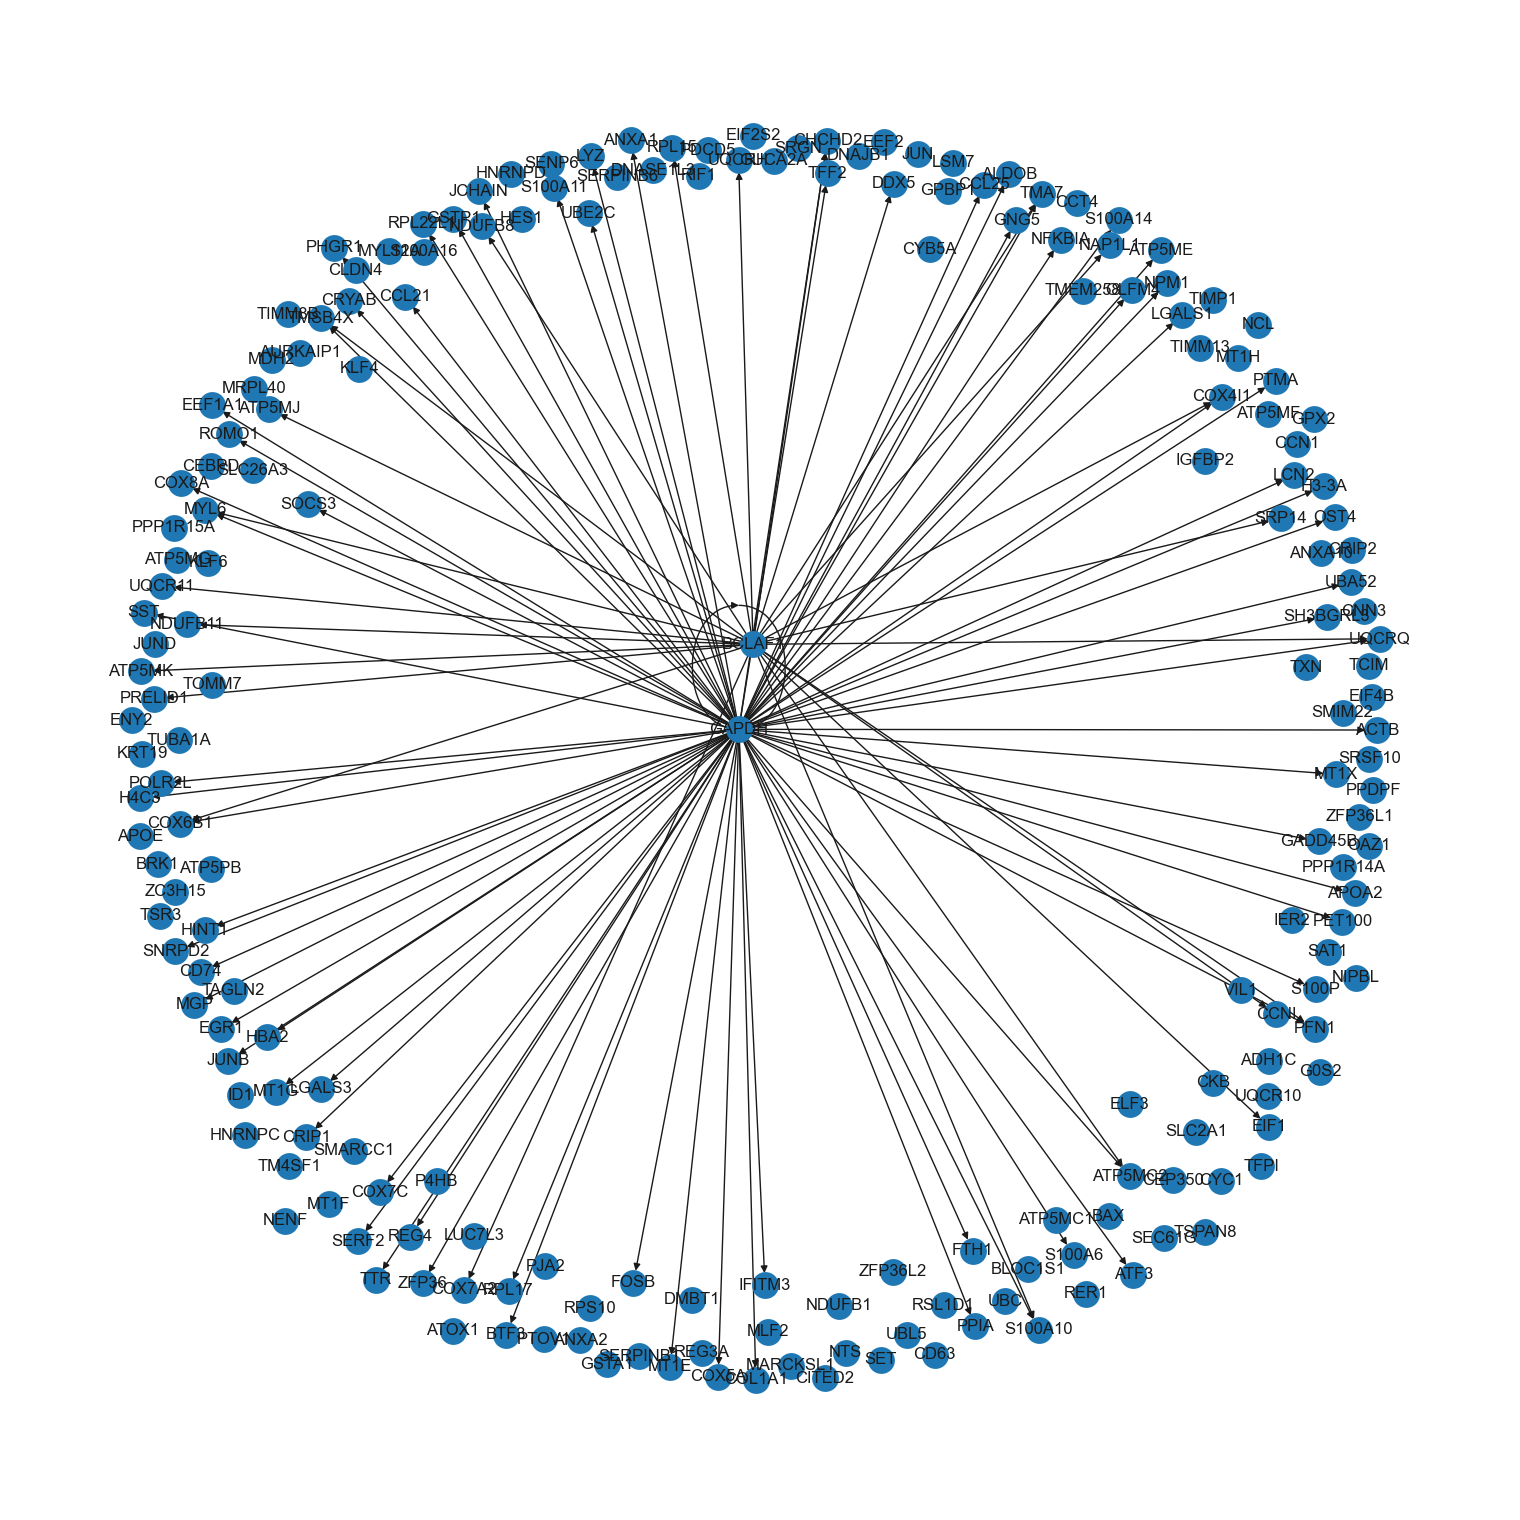

Saved network visualization to grn_community_0.html


In [ ]:
# Plot subgraph for the largest community
G = grn_full.plot_subgraph(community_genes, only=100, interactive=False)

# Create interactive network visualization
pnet = pnx.Network(notebook=True, cdn_resources="remote", directed=True)
pnet.from_nx(G)
#pnet.save_graph(f"Fetal_stem_cells_analysis/1_scPRINT/grn_community_{largest_community}.html")
print(f"Saved network visualization to grn_community_{largest_community}.html")

## Gene Set Enrichment Analysis

Perform enrichment analysis on the identified communities and hub genes.

In [ ]:
enr = gp.enrichr(gene_list=list(G.nodes),
                    gene_sets=['KEGG_2021_Human', 
                            'MSigDB_Hallmark_2020', 
                            'Reactome_2022', 
                            'GO_Biological_Process_2023',
                            'GO_Molecular_Function_2023',
                            'Tabula_Sapiens'],
                    organism='Human',
                    background=grn_full.var.symbol.tolist())

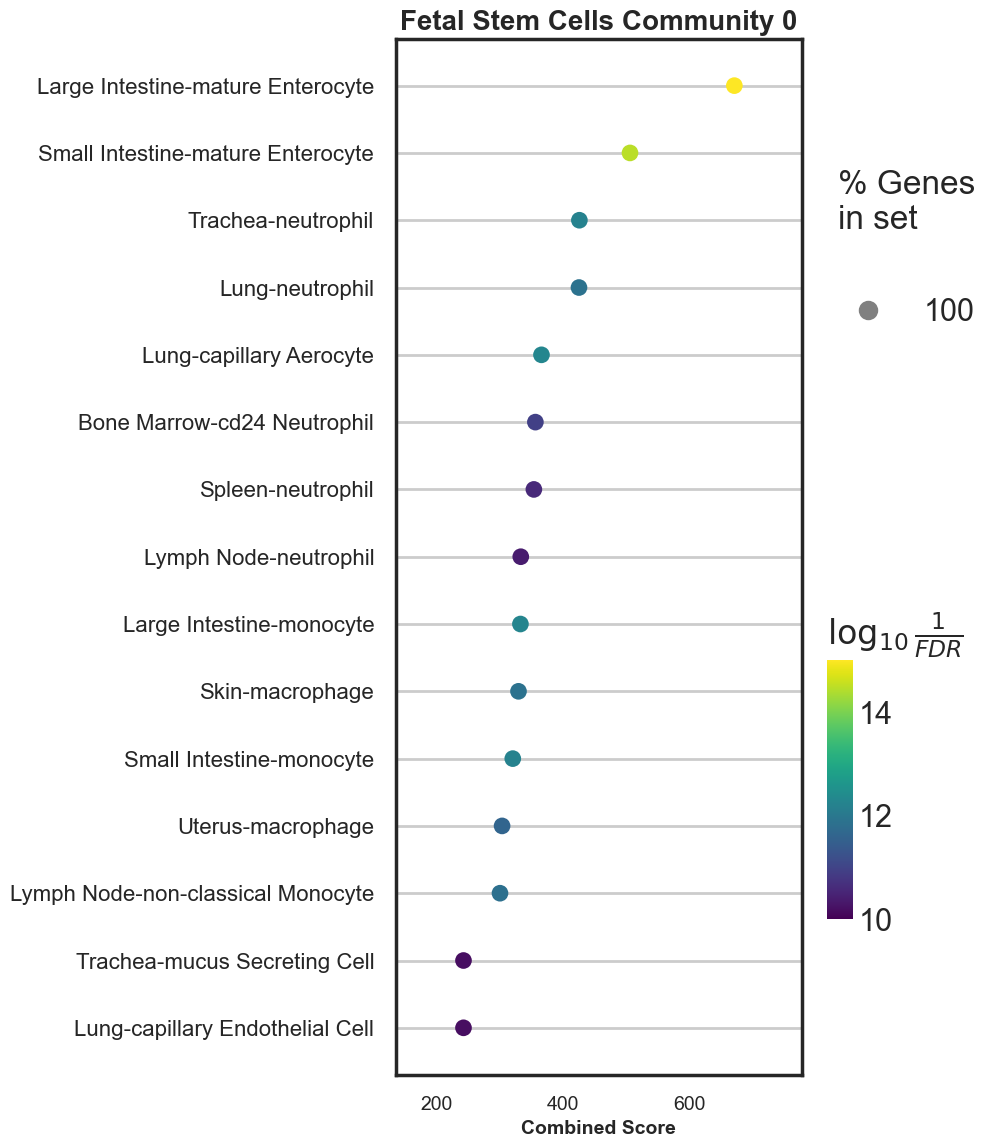

In [52]:
# Create enrichment plot
enr.res2d.Term = enr.res2d.Term.str.split("(").str[0].str[:50]
ax = dotplot(enr.res2d.replace([np.inf, -np.inf], 0).dropna(),
                column="Adjusted P-value",
                title=f'Fetal Stem Cells Community {largest_community}',
                cmap=plt.cm.viridis,
                size=1,
                top_term=15,
                figsize=(10,12), 
                cutoff=0.25)
plt.tight_layout()
plt.show()

In [53]:
enr.res2d.head(20)

,Gene_set,Term,P-value,Adjusted P-value,Old P-value,Old adjusted P-value,Odds Ratio,Combined Score,Genes
0,Tabula_Sapiens,Large Intestine-mature Enterocyte,4.150502e-19,1.946585e-16,0,0,15.854651,671.062181,DDX5;COX4I1;LGALS3;TSPAN8;FTH1;TMSB4X;SH3BGRL3...
1,Tabula_Sapiens,Small Intestine-mature Enterocyte,1.332727e-17,3.125244e-15,0,0,13.028044,506.227046,REG3A;DDX5;COX4I1;GSTP1;MT1X;JCHAIN;TSPAN8;FTH...
2,Tabula_Sapiens,Lung-capillary Aerocyte,3.193210e-15,4.992051e-13,0,0,10.976701,366.377574,IFITM3;DDX5;CEBPD;MT1X;MYL12A;ZFP36L1;SOCS3;ZF...
3,Tabula_Sapiens,Large Intestine-monocyte,4.456667e-15,5.225442e-13,0,0,10.081338,333.131507,PPP1R15A;DDX5;CEBPD;ZFP36L1;SOCS3;DNAJB1;ZFP36...
4,Tabula_Sapiens,Small Intestine-monocyte,6.837502e-15,6.201562e-13,0,0,9.843259,321.051203,DDX5;CEBPD;ZFP36L1;SOCS3;DNAJB1;ZFP36;LGALS1;T...
5,Tabula_Sapiens,Trachea-neutrophil,7.933768e-15,6.201562e-13,0,0,13.129107,426.271212,SRGN;EGR1;CD63;SERPINB1;G0S2;OAZ1;MYL12A;ZFP36...
6,Tabula_Sapiens,Lung-neutrophil,2.013299e-14,1.282646e-12,0,0,13.496629,425.635319,SRGN;PPP1R15A;CD63;CEBPD;G0S2;OAZ1;MYL12A;ZFP3...
7,Tabula_Sapiens,Skin-macrophage,2.187882e-14,1.282646e-12,0,0,10.494208,330.077043,CD63;MT1X;OAZ1;LGALS1;FTH1;TMSB4X;SH3BGRL3;TIM...
8,Tabula_Sapiens,Lymph Node-non-classical Monocyte,2.906650e-14,1.514688e-12,0,0,9.652162,300.850072,CEBPD;OAZ1;ZFP36L1;ZFP36;FTH1;TMSB4X;SH3BGRL3;...
9,Tabula_Sapiens,Uterus-macrophage,5.282956e-14,2.477706e-12,0,0,9.948718,304.149275,CD63;OAZ1;LGALS1;FTH1;TMSB4X;SH3BGRL3;APOE;TIM...


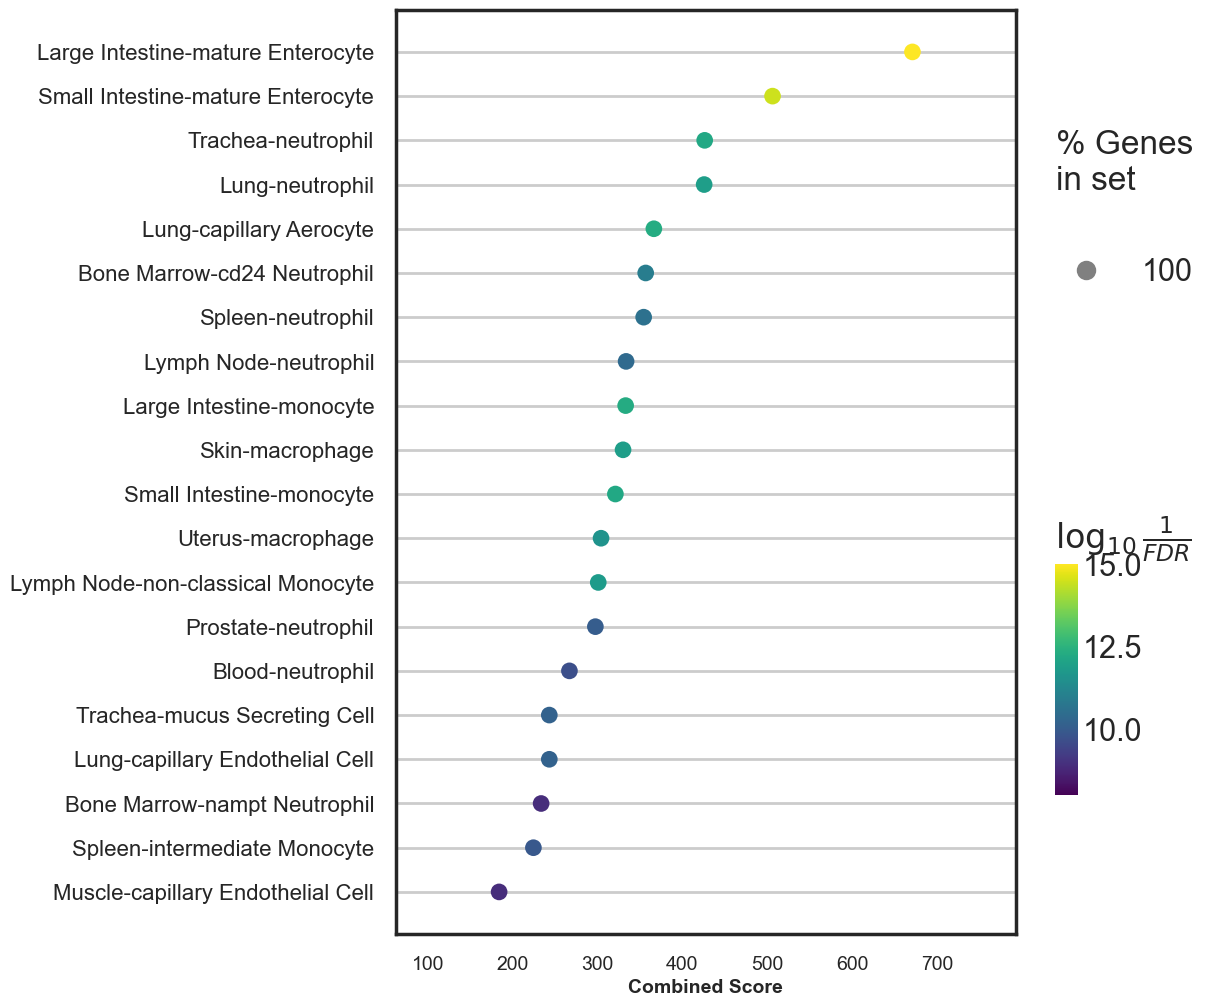

In [54]:
# we make a plot of the enrichment
enr.res2d.Term = enr.res2d.Term.str.split("(").str[0].str.split(',').str[0]
ax = dotplot(enr.res2d.replace([np.inf, -np.inf], 0).dropna(),
             column="Adjusted P-value",
             #title='normal fibro PAGE4',
             cmap=plt.cm.viridis,
             size=1, # adjust dot size
             top_term=20,
             figsize=(10,12), cutoff=0.25)

## Specific Gene Network Analysis

Let's analyze the network around specific genes of interest, similar to the PAGE4 analysis in the cancer tutorial.

Available stem cell markers in the network:
['KLF4', 'MYC', 'GATA6']

Analyzing network around KLF4...
['#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#ff7f0e'] Index(['PRRC2B', 'KRT18', 'RPL26L1', 'GYPC', 'LAGE3', 'GAPDH', 'CRIP2',
       'BCLAF1', 'EIF2B1', 'HES4', 'NIPBL', 'TMEM126A', 'VIM', 'CORO1A',
       'RPSA', 'GSTT1', 'ASH1L', 'KRT8', 'ARHGDIB', 'BTG3', 'MRPS11',
       'HLA-DRB1', 'FKBP7', 'DHX36', 'ZNF148', 'PJA1', 'CD52', 'SDF2L1',
       'SENP6', 'RPS21', 'KLF4'],
      dtype='object', name='symbol_2')


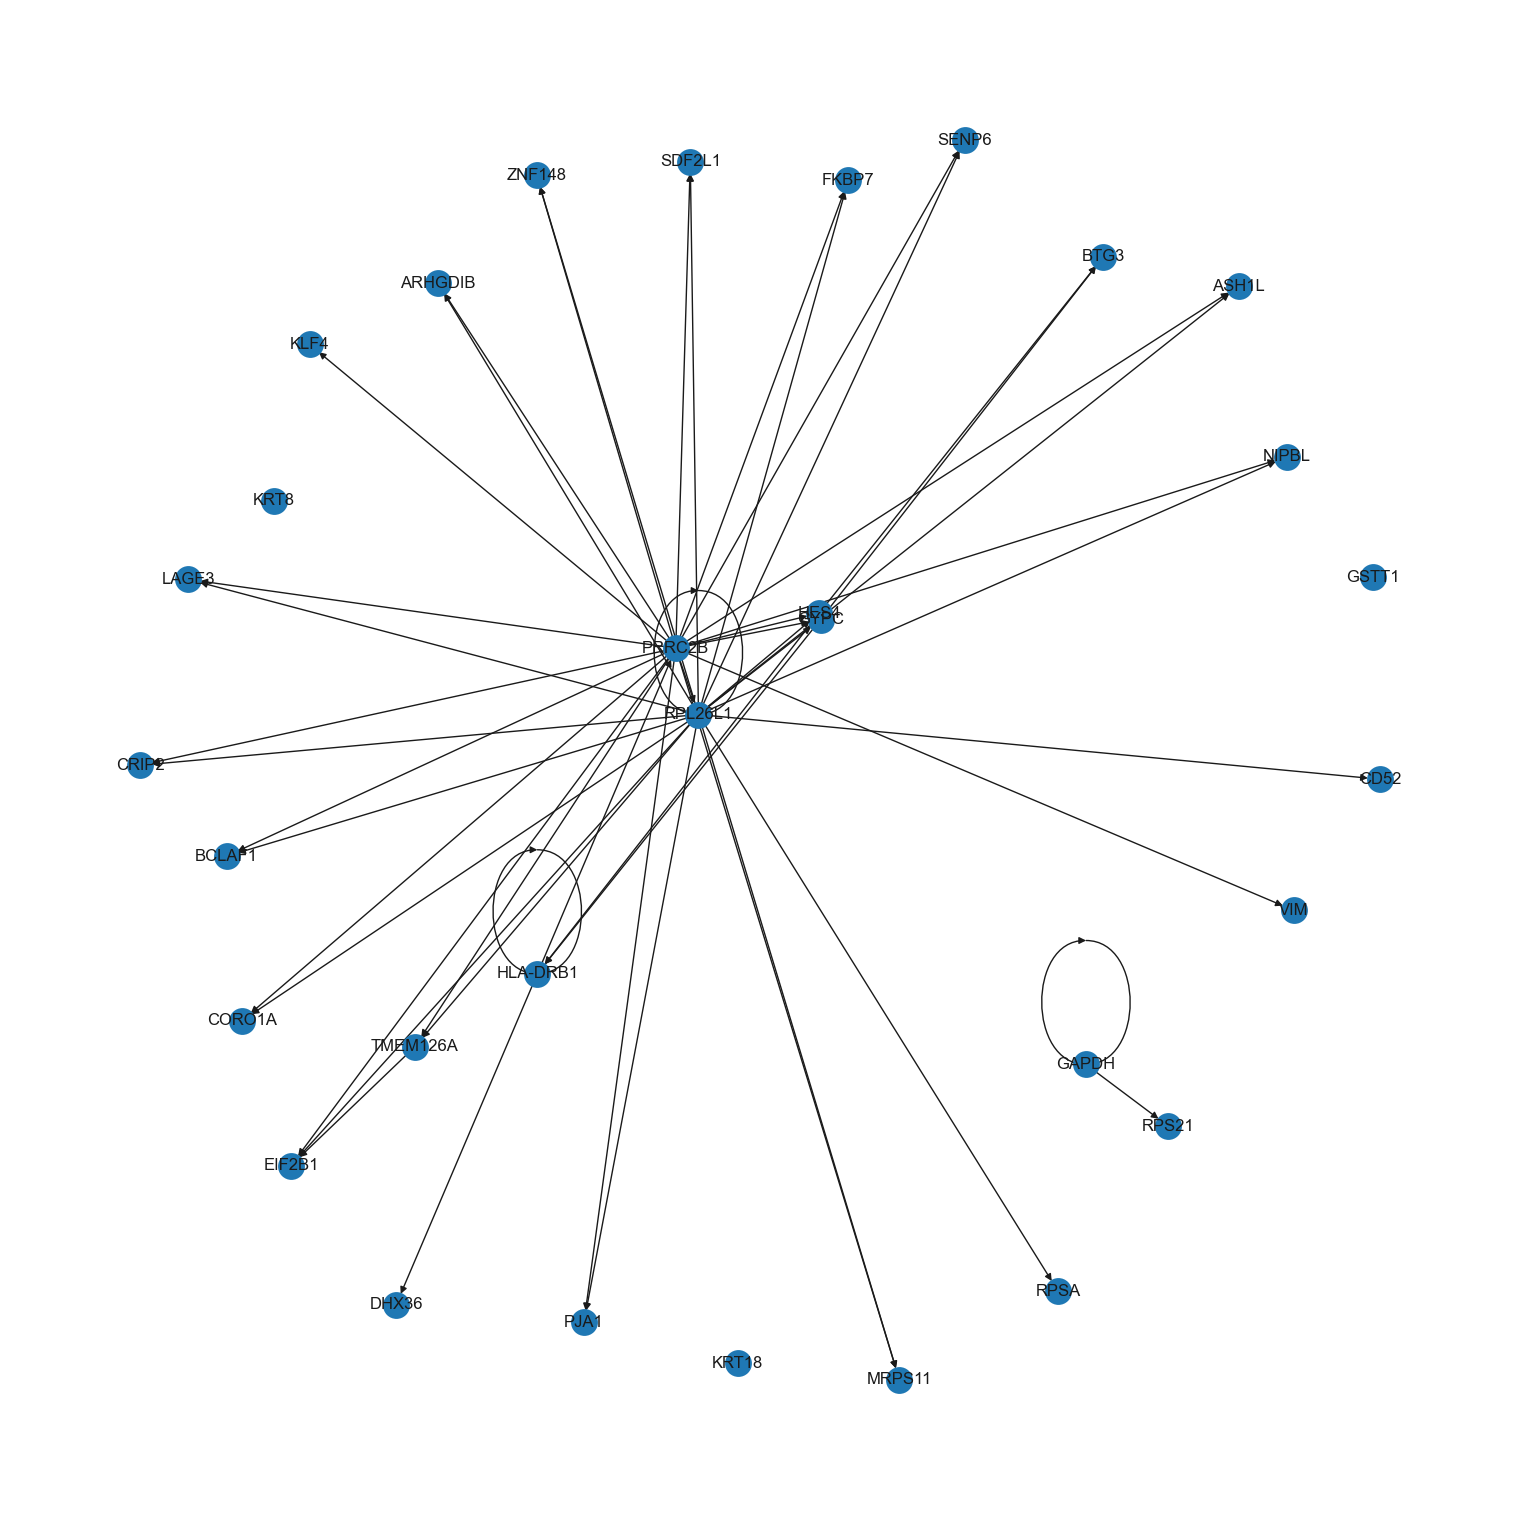

Saved KLF4 network visualization


In [ ]:
# Find interesting genes to focus on (e.g., stem cell markers, developmental genes)
stem_cell_markers = ['SOX2', 'NANOG', 'POU5F1', 'KLF4', 'MYC', 'LIN28A', 'SOX17', 'GATA6']
available_markers = [gene for gene in stem_cell_markers if gene in grn_full.var.index]

print("Available stem cell markers in the network:")
print(available_markers)

if available_markers:
    # Analyze network around the first available marker
    focus_gene = available_markers[0]
    print(f"\nAnalyzing network around {focus_gene}...")
    
    G_focus = grn_full.plot_subgraph(focus_gene, only=50, max_genes=30, interactive=False)
    
    # Create visualization
    pnet = pnx.Network(notebook=True, cdn_resources="remote", directed=True)
    pnet.from_nx(G_focus)
    # Highlight the focus gene
    if focus_gene in G_focus.nodes:
        pnet.get_node(focus_gene)['color'] = "red"
        pnet.get_node(focus_gene)['size'] = 25
    
    pnet.save_graph(f"/Fetal_stem_cells_analysis/1_scPRINT/grn_{focus_gene}_network.html")
    print(f"Saved {focus_gene} network visualization")
else:
    print("No common stem cell markers found. Let's analyze the top hub gene instead.")
    focus_gene = top_hubs.index[0]
    print(f"Analyzing network around top hub gene: {focus_gene}")
    
    G_focus = grn_full.plot_subgraph(focus_gene, only=50, max_genes=30, interactive=False)
    
    pnet = pnx.Network(notebook=True, cdn_resources="remote", directed=True)
    pnet.from_nx(G_focus)
    pnet.get_node(focus_gene)['color'] = "red"
    pnet.get_node(focus_gene)['size'] = 25
    
    #pnet.save_graph(f"/Fetal_stem_cells_analysis/1_scPRINT/grn_{focus_gene}_network.html")

## Summary Statistics

Let's generate some summary statistics about our fetal stem cell gene regulatory network.

In [ ]:
# Summary statistics
print("=== Fetal Stem Cells GRN Summary ===")
print(f"Total genes: {grn_full.n_vars}")
print(f"Total observations: {grn_full.n_obs}")

# Network density
total_possible_edges = grn_full.n_vars * (grn_full.n_vars - 1)
actual_edges = (grn_full.grn > 0).sum().sum()
density = actual_edges / total_possible_edges
print(f"Network density: {density:.4f}")

# Top connected genes
print(f"\nTop 5 most connected genes:")
for i, (gene, connections) in enumerate(top_hubs.head(5).items()):
    print(f"{i+1}. {gene}: {connections:.3f}")

# Community information
print(f"\nNumber of communities: {len(community_counts)}")
print(f"Largest community size: {community_counts.iloc[0]}")
print(f"Average community size: {community_counts.mean():.1f}")

# Save processed data
print(f"\nProcessed GRN saved to: grn_fetal_stem_cells_processed.h5ad")

=== Fetal Stem Cells GRN Summary ===
Total genes: 2955
Total observations: 11774
Network density: 1.0003

Top 5 most connected genes:
1. PRRC2B: 106.764
2. RPL26L1: 99.827
3. GYPC: 65.443
4. TMEM126A: 61.628
5. HES4: 57.853

Number of communities: 63
Largest community size: 200
Average community size: 46.9

Processed GRN saved to: grn_fetal_stem_cells_processed.h5ad
